# How does `_obc` compare to `bry` files?

The `bry` files contains the forcings given. 

About the `bry` files:

- coordinates: (s_rho: 42, eta_rho: 351, xi_rho: 901, eta_u: 351, xi_u: 900, eta_v: 350, xi_v: 901)
- ocean_time: daily from `it-2` to `it+4` at T12 (7 timesteps)
- other variables: Y_X, where Y=(temp, salt, zeta, u, v, vbar, ubar) and X=(west, east, south, north)

In [1]:
%matplotlib widget
%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from utils import get_boundary_slice, plot_2boundary_slice
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 18

In [ ]:
# Get the boundary file
forcing_dir='https://thredds.met.no/thredds/dodsC/foccus/'
year = 2024
month = '03'
day = 10
ds_bry = xr.open_dataset(forcing_dir + f'/{year}/{month}/norshelf_bry_{year}{month}{day}T00Z.nc')

In [ ]:
# Then get the analysis
dir = f'https://thredds.met.no/thredds/dodsC/foccus/'

outer = 1
ds = xr.open_dataset(dir + f'norshelf-ana_fwd_{year}{month}{day}T00Z_outer{outer}.nc')

### The bry files have a different time step, need to make sure we are comparing the same time & date!

In [6]:
# Need to find the time indices that correspond to the same time for the two datasets:
it = -5; it_bry = 1
t = ds.ocean_time.values[it]
t_bry = ds_bry.ocean_time.values[it_bry]
print(f"These are identical (t[it={it}] == t_bry[it={it_bry}]):  \n{t} \n{t_bry}")

These are identical (t[it=-5] == t_bry[it=1]):  
2024-03-09T12:00:00.000000000 
2024-03-09T12:00:00.000000000


### Load in the boundary variables 
(select a variable)

**NOTE**: the Norkyst domain is "Laying sideways" (meridian direction alon y-axis) in the ROMS simulation. This means that for the ROMS coordinate system "west/east" direction (pointing along x-axis) is in fact compass direction south/north. This is important since ROMS outputs variable names with endings like "west", "south", "east" and "north". 

ROMS --> compass \
west --> south \
south--> east \
east --> north \
north--> west 

In [7]:
# Using the indices form above, e.g. time 2024-03-09T12:00:00.000000000
var_name = 'salt'
direction = 'west'

var_west     = get_boundary_slice(ds,    var_name,           direction=direction,itime=it)            # (42, 901)
var_west_obc = get_boundary_slice(ds,    var_name,           direction=direction,itime=it,obc=True)   # (42, 901)
# selecting western compass direction (=north in roms)
var_bry      = ds_bry[var_name +'_north'].isel(ocean_time=it_bry).values                           # (42, 901)

In [8]:
# Also get the velocities (v)
v_west = get_boundary_slice(ds, 'v', direction=direction,itime=it)
v_west_obc = get_boundary_slice(ds, 'v', direction=direction,itime=it,obc=True)

#def convert_var_binary(var):
#    var_out = np.where(var > 0, 1, -1)
#    var_out = np.where(var ==0, 0, var_out)
#    return var_out

#v_binary = convert_var_binary(v_west) 
#v_binary_obc = convert_var_binary(v_west_obc)

Text(0.5, 1.0, 'salt_bry')

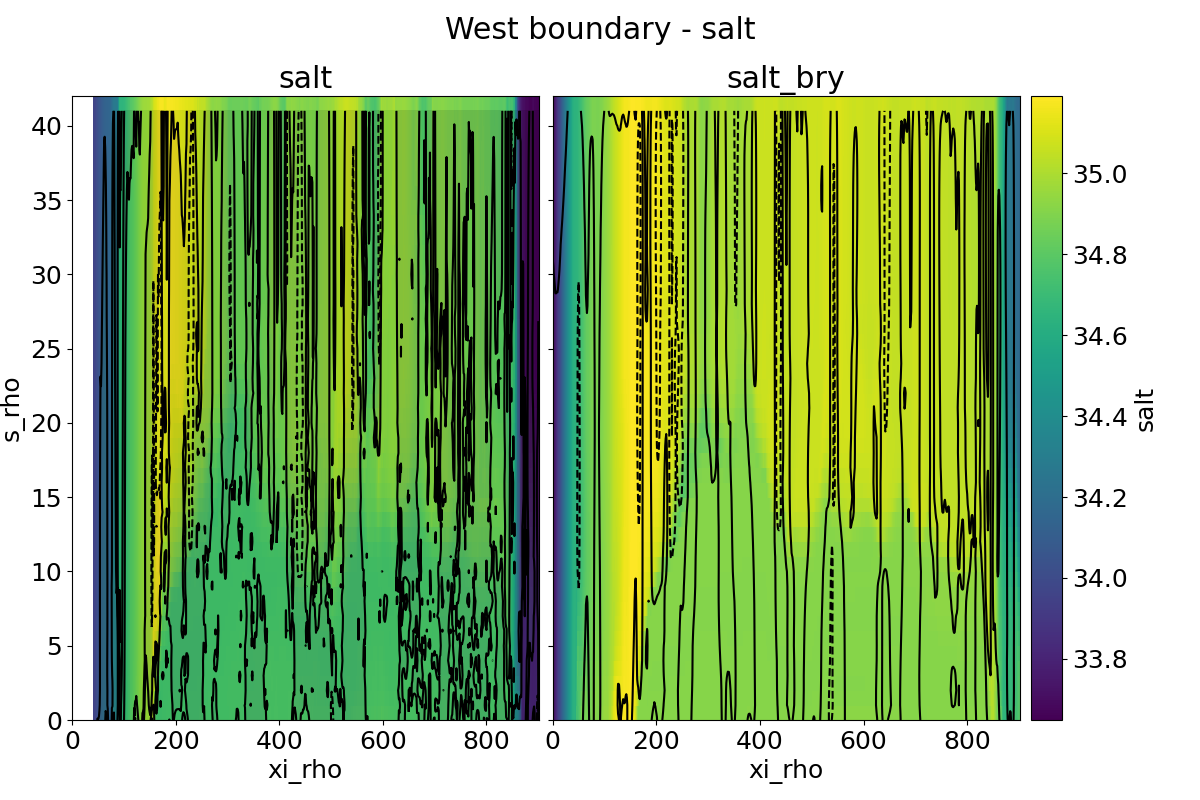

In [9]:
kwargs = {}#{'vmin': 33, 'vmax': 35.2} # for salt...
#fig, axs = plot_2boundary_slice(var_name, var_west, var_west_obc, **kwargs)
fig, axs = plot_2boundary_slice(var_name, var_west, var_bry, **kwargs)

# Even if v is not on the same grid, plot it together
kwargs = {'levels': np.linspace(-0.3,0.3,7),'colors':'black'}
axs[0].contour(v_west,**kwargs)
axs[0].contourf(v_west,levels=kwargs['levels'],colors=['k','g'],alpha=0.1)
axs[1].contour(v_west_obc,**kwargs)

axs[0].set_title(f'{var_name}')
axs[1].set_title(f'{var_name}_bry')

In [10]:
print(v_west_obc.min(),v_west_obc.max())

-0.2099125 0.22218849


### Plotting the difference between obc and bry + v contour
NOTE: removing the first and last index in xa_rho direction (does this mean they are not on the same grid?)

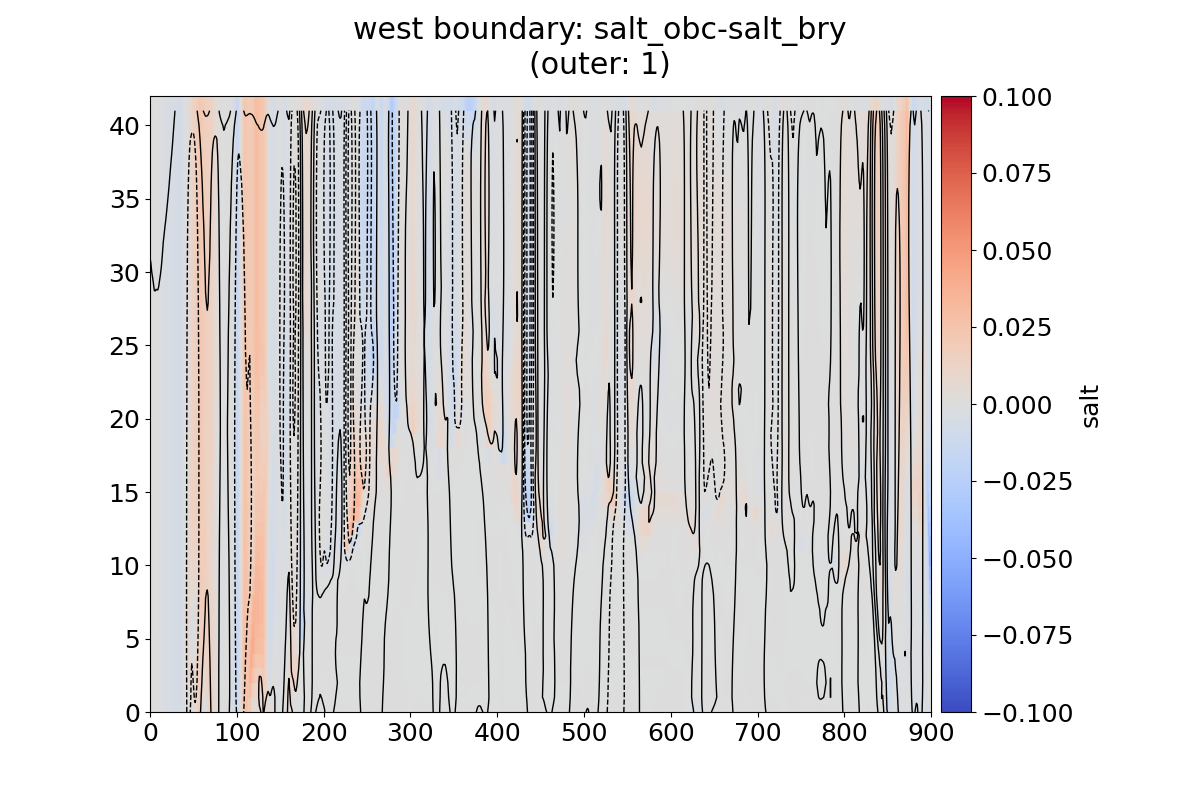

In [11]:
diff = var_west_obc[:,1:900]-var_bry[:,1:900] # !!!

fig2, axx = plt.subplots(1)
fig2.suptitle(f'{direction} boundary: {var_name}_obc-{var_name}_bry\n(outer: {outer})')
kwargs = {'vmin': -0.1, 'vmax': 0.1, 'cmap':'coolwarm'}
#kwargs = {'cmap':'coolwarm'} 
im = axx.pcolor(diff, **kwargs)

# Even if v is not on the same grid, plot it together
#levels = [-0.2,-0.1,-0.05,0,0.05,0.15,0.22] 
levels = np.linspace(-0.3,0.3,11)
kwargs = {'levels': levels,'colors':'black'} #'cmap':'vanimo','linestyles': '--' #ListedColormap(["black", "orange"])
cs = axx.contour(v_west_obc,**kwargs)
cs.set_linewidths(1)
# Thicken the zero contour.
#lws = np.resize(cs.get_linewidth(), len(levels))
#lws[np.argwhere(levels==0)] = 2
#cs.set_linewidth(lws)

# Overlay velocity with large opacity since 
#cf = axx.contourf(v_west_obc,levels=levels,colors=['k','g'],alpha=0.1)


fig2.colorbar(im,ax=axx, pad=0.01, label=f'{var_name}')
# make a colorbar for the contour lines
#cb = fig.colorbar(cs, pad=0.01, shrink=0.8)

# TODO is there something wrong when making contour lines?? see when plot vel with overlay of vel

### TODO: make large grid plots with all boundaries for each variable?
temp, salt, zeta, u, v, ubar, vbar

In [13]:
diff[diff!=0].shape

(37758,)

In [14]:
for v in ds_bry.variables:
    print(v)

ocean_time
temp_west
temp_east
temp_south
temp_north
salt_west
salt_east
salt_south
salt_north
zeta_west
zeta_east
zeta_south
zeta_north
u_west
u_east
u_south
u_north
v_west
v_east
v_south
v_north
vbar_west
vbar_east
vbar_south
vbar_north
ubar_west
ubar_east
ubar_south
ubar_north


#### TODO: can I use get_boundary_slice for all/many timesteps?

In [15]:
print(it,it_bry)

-5 1


In [16]:
ds.ocean_time.size

17

In [17]:
var_west     = get_boundary_slice(ds,var_name,direction=direction,itime=np.arange(17)) # (17, 42, 901)
var_west.shape

(17, 42, 901)

In [18]:
var_west_obc = get_boundary_slice(ds,var_name,direction=direction,itime=np.arange(17),obc=True)   # (17,42, 901)
var_west_obc.shape

(17, 42, 901)

In [19]:
var_bry_time      = ds_bry[var_name +'_north'].isel(ocean_time=np.arange(7)).values    
var_bry_time.shape

(7, 42, 901)